# NLP Sentiment Analysis using RNN and LSTM

## importing libraries

In [95]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [97]:
import tensorflow as tf

In [98]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [99]:
from tensorflow.keras.models import Sequential

In [100]:
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

## Load Dataset

In [101]:
df = pd.read_csv('../data/imbalanced_data.csv')

In [102]:
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [103]:
df.tail()

,id,label,tweet
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."
31961,31962,0,thank you @user for you follow


In [104]:
df.sample(10)

,id,label,tweet
10570,10571,0,makes a very good point
31723,31724,0,@user ramadan to all mussulmanic twitter f...
14550,14551,0,i am so for @user &amp; #bristolpalin ... an...
2936,2937,0,looking at old posts from my old twitter accou...
28107,28108,0,"@user ha ha, is that it? your very best respon..."
26950,26951,0,"@user : ""#orlando gay nightclub shooting: 5..."
24228,24229,0,"@user when is your ballard, seattle, wa locati..."
8273,8274,0,"@user motm in first two games in #euro2016, @..."
30032,30033,1,are you #hispanic &amp; â¦ like the are stom...
1675,1676,0,"happy thoughts, happy lives , visualize what y..."


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [106]:
df.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

In [107]:
df.duplicated().sum()

0

## Text Cleaning

In [108]:
def clean_text(text):

    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)

    return text

In [109]:
# applying cleaning

df['clean_tweet'] = df['tweet'].apply(clean_text)

In [110]:
df[['tweet', 'clean_tweet']].sample(10)

,tweet,clean_tweet
27483,@user edible wild plants - wintergreen #peac...,edible wild plants wintergreen peace love ...
29667,awesome time one the water !!!! soy_nigi_holla...,awesome time one the water soynigiholla feahe...
6728,herbal sleep remedies that work!! #altwaystoh...,herbal sleep remedies that work altwaystoheal...
2775,#model i love u take with u all the time in ...,model i love u take with u all the time in u...
12220,figuring out how to work with this ð®ð½ #p...,figuring out how to work with this police fut...
2637,hello #maggystylerd #rd #lifestyle #lifestyleb...,hello maggystylerd rd lifestyle lifestyleblogg...
27835,"thanks to dom, either my body fat is slowly de...",thanks to dom either my body fat is slowly dec...
15480,i'm not saying all that but okayðð¶,im not saying all that but okay
11735,last bit of my work to do ððð. #gym ...,last bit of my work to do gym
26131,who fuckin coat? ð­ð­ ugly ass lmfao,who fuckin coat ugly ass lmfao


## Define Features and Target

In [111]:
X = df['clean_tweet']

In [112]:
y = df['label']

## Train Test Split

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=42
                                                    )

## Tokenization

In [114]:
max_words = 5000

In [115]:
tokenizer = Tokenizer(num_words=max_words)
tokenizer

In [116]:
tokenizer.fit_on_texts(X_train)

## Convert Text to Sequences

In [117]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_train_seq

[[146, 214, 116, 2323, 1319, 8, 1, 818, 171, 232, 418, 3],
 [1501, 26, 52, 362, 9, 1, 79, 3178],
 [88, 88, 172, 1960, 528],
 [332, 16, 10, 3, 263, 497],
 [19, 2, 480, 1, 862, 3916, 4, 3917, 8, 1961],
 [269, 686, 13, 560, 2496, 2177, 217, 759, 702, 13, 3515, 5, 1242],
 [2178, 787, 2, 1370, 6, 2912, 3, 1039, 202, 2179, 20, 14],
 [4494, 2913, 2, 3918, 147, 123, 102, 267, 39],
 [1, 862, 175, 7, 38, 84, 64, 25, 70, 507, 12],
 [7, 770, 5, 68, 28, 126, 3516],
 [98, 129, 218],
 [21, 212, 27, 139, 44, 1, 21, 992, 13, 5, 388, 444, 1284, 661],
 [47, 840, 2043, 61, 1629, 1243, 47, 2043],
 [20, 662, 37, 349, 1059, 581, 120, 26, 35],
 [760,
  14,
  395,
  2,
  412,
  2,
  11,
  947,
  102,
  2,
  53,
  151,
  2,
  703,
  13,
  419,
  529,
  4,
  412,
  106],
 [14, 10, 43, 365, 44, 73],
 [37, 34, 3, 41, 10, 1, 427, 802],
 [25, 55, 1244, 249, 1244],
 [32, 4, 66, 74, 2, 36, 86, 73, 66, 23, 16, 169, 23, 139, 1689],
 [89, 2, 13, 2044, 3919],
 [2324, 54, 42, 1, 226, 4495, 2045, 2914, 3920, 3179, 4496, 623

In [118]:
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_seq

[[11, 416, 404, 11, 70, 10, 4, 404, 25, 132, 70, 132],
 [7, 87, 4, 33, 17, 735, 11, 13, 58, 106, 1654, 528, 576],
 [2952, 1, 3541, 926, 14, 867, 52, 3, 98, 9, 2433, 34, 7, 11, 766, 5, 121],
 [72, 14, 348, 2403, 88],
 [117, 67, 18, 229, 2564, 3, 3276, 442, 175, 60, 4665],
 [137, 3831, 423, 99],
 [3, 114, 203],
 [1108, 57, 1, 98, 5, 74, 2, 17, 3487, 528],
 [6, 48, 8, 1, 739, 166, 174, 5, 183, 19],
 [58, 1982, 476, 202, 114, 136, 44, 2, 610, 5, 657, 366],
 [709, 11, 1020, 10, 3384, 130, 2074, 499],
 [85, 3, 3332, 1311, 721],
 [219, 81, 246, 7, 6, 11, 681, 371, 41, 1],
 [585,
  690,
  21,
  275,
  41,
  1,
  1260,
  9,
  8,
  3,
  228,
  557,
  80,
  54,
  3086,
  61,
  3,
  2858,
  428,
  966,
  912,
  3,
  651,
  2268,
  256],
 [25, 55, 8, 23, 76, 190, 88, 1806, 246],
 [4, 3177, 65, 192, 14, 4912],
 [811, 63, 1710, 383, 1521, 23, 307, 1420, 12, 627, 1044],
 [190, 15, 6, 1504, 6, 99, 38],
 [95,
  35,
  4,
  34,
  1840,
  3,
  85,
  61,
  58,
  804,
  14,
  10,
  19,
  4463,
  45,
  43,
  

## Padding Sequences

In [119]:
max_length = 100

In [120]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length
)

In [121]:
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length
)

In [122]:
## Check Shape
X_train_pad.shape


(25569, 100)

In [123]:
X_test_pad.shape

(6393, 100)

In [124]:
X.shape

(31962,)

In [125]:
y.shape

(31962,)

# SIMPLE RNN MODEL

In [126]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Input

In [127]:
rnn_model = Sequential()
rnn_model

<Sequential name=sequential_7, built=False>

In [128]:
rnn_model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_length
    )
)

e:\sentiment analysis on twitter data\venv\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [129]:
rnn_model.add(
    SimpleRNN(64)
)

In [130]:
rnn_model.add(
    Dropout(0.5)
)

In [131]:
rnn_model.add(
    Dense(1, activation='sigmoid')
)

In [132]:
rnn_model = Sequential()

rnn_model.add(Input(shape=(max_length,)))

rnn_model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128
    )
)

rnn_model.add(SimpleRNN(64))

rnn_model.add(Dropout(0.5))

rnn_model.add(Dense(1, activation='sigmoid'))

In [133]:
## Compile RNN Model
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model

<Sequential name=sequential_8, built=True>

In [134]:
# Model Summary
rnn_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,417 (2.49 MB)

 Trainable params: 652,417 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

In [135]:
# Train RNN Model
rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9236 - loss: 0.2570 - val_accuracy: 0.9531 - val_loss: 0.1397
Epoch 2/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9664 - loss: 0.0985 - val_accuracy: 0.9537 - val_loss: 0.1581
Epoch 3/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9894 - loss: 0.0360 - val_accuracy: 0.9439 - val_loss: 0.1914
Epoch 4/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9940 - loss: 0.0209 - val_accuracy: 0.9425 - val_loss: 0.2382
Epoch 5/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.9972 - loss: 0.0104 - val_accuracy: 0.9175 - val_loss: 0.3181


In [136]:
# Evaluate RNN Model
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    X_test_pad,
    y_test
)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9202 - loss: 0.2785


In [137]:
print("RNN Accuracy:", rnn_accuracy)

RNN Accuracy: 0.9206945300102234


In [138]:
# Predict Using RNN
rnn_pred = rnn_model.predict(X_test_pad)
rnn_pred = (rnn_pred > 0.5).astype(int)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [139]:
# Classification Report
print(classification_report(y_test, rnn_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96      5937
           1       0.46      0.62      0.53       456

    accuracy                           0.92      6393
   macro avg       0.71      0.78      0.74      6393
weighted avg       0.93      0.92      0.93      6393



In [140]:
# Confusion Matrix
rnn_cm = confusion_matrix(y_test, rnn_pred)
rnn_cm


array([[5603,  334],
       [ 173,  283]], dtype=int64)

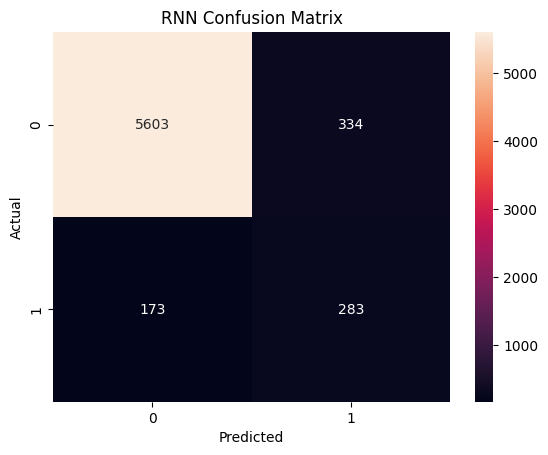

In [141]:
sns.heatmap(rnn_cm, annot=True, fmt='d')
plt.title('RNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

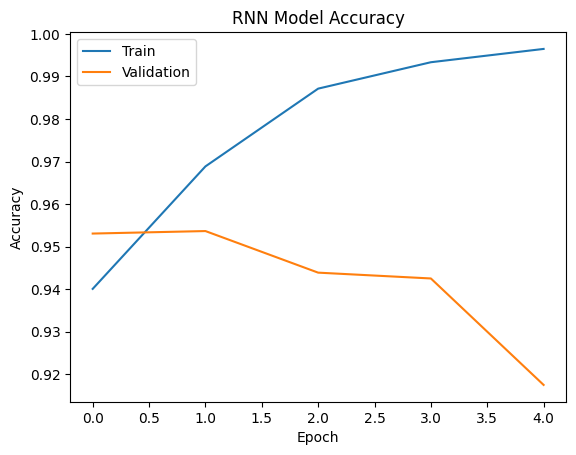

In [142]:
# RNN Accuracy Graph
plt.plot(rnn_history.history['accuracy'])
plt.plot(rnn_history.history['val_accuracy'])

plt.title('RNN Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

# LSTM MODEL

In [143]:
from tensorflow.keras.layers import LSTM

In [144]:
lstm_model = Sequential()
lstm_model

<Sequential name=sequential_9, built=False>

In [145]:
lstm_model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_length
    )
)

e:\sentiment analysis on twitter data\venv\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [146]:
lstm_model.add(
    LSTM(64)
)

In [147]:
lstm_model.add(
    Dropout(0.5)
)

In [148]:
lstm_model.add(
    Dense(1, activation='sigmoid')
)

In [149]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_length,)))

lstm_model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128
    )
)

lstm_model.add(LSTM(64))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(1, activation='sigmoid'))

In [150]:
# Compile LSTM Model
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [151]:
# LSTM Summary
lstm_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 689,473 (2.63 MB)

 Trainable params: 689,473 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [152]:
# Train LSTM Model
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.9296 - loss: 0.2402 - val_accuracy: 0.9537 - val_loss: 0.1325
Epoch 2/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 49s 77ms/step - accuracy: 0.9711 - loss: 0.0894 - val_accuracy: 0.9558 - val_loss: 0.1346
Epoch 3/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 49s 76ms/step - accuracy: 0.9789 - loss: 0.0624 - val_accuracy: 0.9558 - val_loss: 0.1537
Epoch 4/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 34s 52ms/step - accuracy: 0.9853 - loss: 0.0440 - val_accuracy: 0.9476 - val_loss: 0.1696
Epoch 5/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.9916 - loss: 0.0269 - val_accuracy: 0.9486 - val_loss: 0.2137


In [153]:
# Evaluate LSTM Model
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test
)
print("LSTM Accuracy:", lstm_accuracy)

200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9505 - loss: 0.1754
LSTM Accuracy: 0.9518222808837891


In [154]:
# Predict Using LSTM
lstm_pred = lstm_model.predict(X_test_pad)
lstm_pred = (lstm_pred > 0.5).astype(int)

200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step


In [155]:
# Classification Report
print(classification_report(y_test, lstm_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      5937
           1       0.69      0.58      0.63       456

    accuracy                           0.95      6393
   macro avg       0.83      0.78      0.80      6393
weighted avg       0.95      0.95      0.95      6393



In [156]:
# Confusion Matrix
lstm_cm = confusion_matrix(y_test, lstm_pred)
lstm_cm

array([[5820,  117],
       [ 191,  265]], dtype=int64)

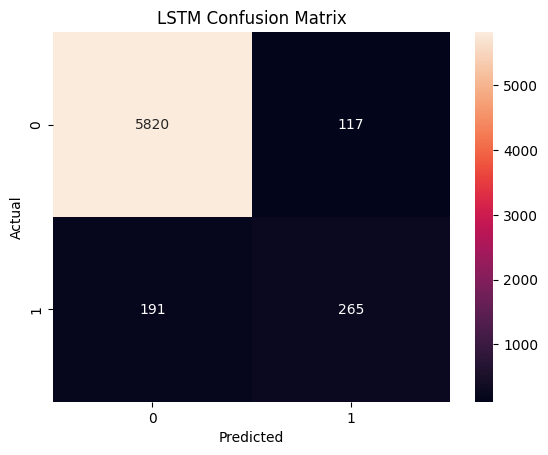

In [157]:
sns.heatmap(lstm_cm, annot=True, fmt='d')
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

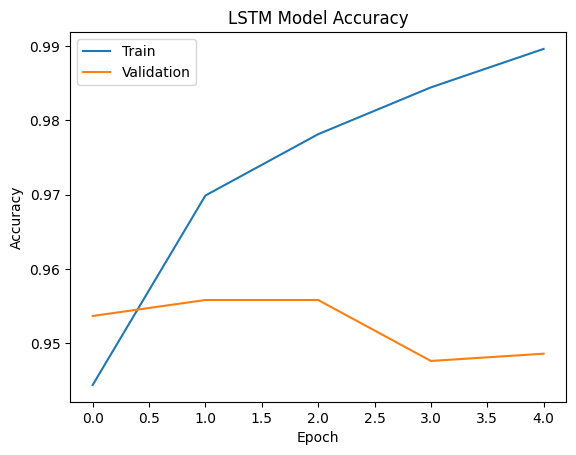

In [158]:
# LSTM Accuracy Graph
plt.plot(lstm_history.history['accuracy'])
plt.plot(lstm_history.history['val_accuracy'])

plt.title('LSTM Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

## Compare RNN vs LSTM


In [159]:
models = ['RNN', 'LSTM']
accuracies = [rnn_accuracy, lstm_accuracy]
accuracies

[0.9206945300102234, 0.9518222808837891]

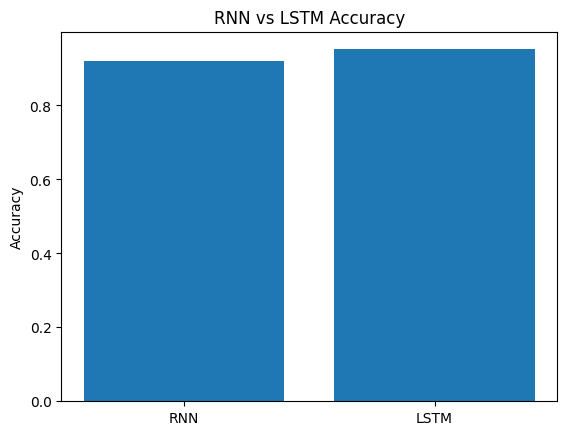

In [160]:

plt.bar(models, accuracies)

plt.title('RNN vs LSTM Accuracy')

plt.ylabel('Accuracy')

plt.show()

## Model saving

In [161]:
# Save RNN Model
rnn_model.save('../Models/rnn_sentiment_model.h5')


In [162]:
# Save LSTM Model
lstm_model.save('../Models/lstm_sentiment_model.h5')

In [163]:
# Save Tokenizer
import pickle
pickle.dump(
    tokenizer,
    open('../Models/tokenizer.pkl', 'wb')
)

## Test Custom Input

In [164]:
sample = "I love this movie"

In [165]:
sample = clean_text(sample)


In [166]:
sample_seq = tokenizer.texts_to_sequences([sample])


In [167]:
sample_pad = pad_sequences(
    sample_seq,
    maxlen=max_length
)

In [168]:
# RNN Prediction
rnn_result = rnn_model.predict(sample_pad)
print(rnn_result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
[[0.00224316]]


In [169]:
# Final Output
if rnn_result[0][0] > 0.5:
    print("Negative Sentiment")
else:
    print("Positive Sentiment")

Positive Sentiment


In [170]:
# LSTM Prediction
lstm_result = lstm_model.predict(sample_pad)
print(lstm_result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[0.00141604]]


In [171]:
# Final Output
if lstm_result[0][0] > 0.5:
    print("Negative Sentiment")
else:
    print("Positive Sentiment")

Positive Sentiment
